# Agentic AI with LangGraph

$\bullet$ AI Agent can make decisions and take actions on its own to achieve a goal without being told exactly what to do at every step. (There has to be some level of control, but within that control it can take autonomous decisions)  
$\bullet$ Agentic AI is a system using one or more agents.

$$
{\small
\begin{array}{|l|c|c|c|c|c|}
\hline
\textbf{Type} & \textbf{Reactive} & \textbf{Tool Use} & \textbf{Reasoning} & \textbf{Planning} & \textbf{Proactivity} \\
\hline
\text{RAG Chatbot} & \checkmark & \times & \times & \times & \times \\
\hline
\text{Tool-Augmented Chatbot} & \checkmark & \checkmark & \times & \times & \times \\
\hline
\text{Agentic AI} & \checkmark & \checkmark & \checkmark & \checkmark & \checkmark \\
\hline
\end{array}
}
$$

$\bullet$ Langgraph helps you build reliable agents, provides a more expressive framework to build highly customizable, complex agents.  
$\bullet$ Langgraph excels at graph-based, stateful orchestration - e.g. multi-step, workflows with memory, streaming, human-in-the-loop control.

### LangChain vs LangGraph vs LangSmith

$\bullet$ Below is a linear workflow which is called a "chain" and whenever you want to build this kind of workflows, LangChain framework is ideal.
$$
Start → [Step 1] → [Step 2] → [LLM] → [Step 3] → [LLM] → End
$$
$\bullet$ But if you want to build complex workflows LangGraph is the option to use.

$$
{\small
\begin{array}{|l|l|l|}
\hline
\textbf{Feature} & \textbf{LangChain} & \textbf{LangGraph} \\
\hline

\textbf{Purpose} & 
\text{Toolkit to build LLM apps (chains, tools, agents)} & 
\text{Framework to manage complex workflows with state} \\
\hline

\textbf{Style} & 
\text{Linear or reactive chains} & 
\text{Graph-based, supports loops, retries, memory} \\
\hline

\textbf{Best Use Case} & 
\text{Simple chatbots, RAG apps, tool usage} & 
\text{Multi-step workflows, agents with memory, conditional paths} \\
\hline

\textbf{State Handling} & 
\text{Stateless or partially stateful} & 
\text{Fully stateful; remembers and transitions based on logic} \\
\hline

\textbf{Example Use} & 
\text{``Book a flight'' using a flight API} & 
\text{``Plan a vacation'' (ask budget $\rightarrow$ choose flights $\rightarrow$ book hotel $\rightarrow$ loop if error)} \\
\hline

\end{array}
}
$$

$\bullet$ For observability, debugging, testing and monitoring, LangSmith is used.

In [1]:
# Importing essential libraries
from typing import TypedDict, Literal, Annotated
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
load_dotenv()

True

### Creating a Simple Graph

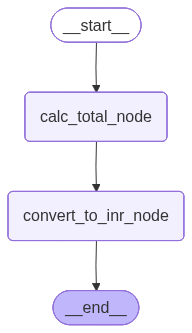

In [2]:
class PortfolioState(TypedDict):
    amount_usd: float
    total_usd: float
    total_inr: float

def calc_total(state: PortfolioState) -> PortfolioState:
    state['total_usd'] = state['amount_usd'] * 1.08
    return state

def convert_to_inr(state: PortfolioState) -> PortfolioState:
    state['total_inr'] = state['total_usd'] * 85
    return state

builder = StateGraph(PortfolioState)
builder.add_node("calc_total_node", calc_total)
builder.add_node("convert_to_inr_node", convert_to_inr)
builder.add_edge(START, "calc_total_node")
builder.add_edge("calc_total_node", "convert_to_inr_node")
builder.add_edge("convert_to_inr_node", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [3]:
graph.invoke({"amount_usd": 1000})

{'amount_usd': 1000, 'total_usd': 1080.0, 'total_inr': 91800.0}

### Creating a Graph with Conditions

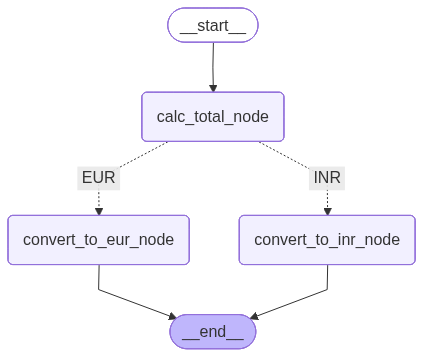

In [4]:
class PortfolioState(TypedDict):
    amount_usd: float
    total_usd: float
    target_currency: Literal["INR", "EUR"]
    total: float

def calc_total(state: PortfolioState) -> PortfolioState:
    state['total_usd'] = state['amount_usd'] * 1.08
    return state

def convert_to_inr(state: PortfolioState) -> PortfolioState:
    state['total'] = state['total_usd'] * 85
    return state

def convert_to_eur(state: PortfolioState) -> PortfolioState:
    state['total'] = state['total_usd'] * 0.9
    return state

def choose_conversion(state: PortfolioState) -> str:
    return state["target_currency"]

builder = StateGraph(PortfolioState)
builder.add_node("calc_total_node", calc_total)
builder.add_node("convert_to_inr_node", convert_to_inr)
builder.add_node("convert_to_eur_node", convert_to_eur)
builder.add_edge(START, "calc_total_node")
builder.add_conditional_edges("calc_total_node", choose_conversion, {"INR": "convert_to_inr_node", "EUR": "convert_to_eur_node",})
builder.add_edge(["convert_to_inr_node", "convert_to_eur_node"], END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
graph.invoke({"amount_usd": 1000, "target_currency": "INR"})

{'amount_usd': 1000,
 'total_usd': 1080.0,
 'target_currency': 'INR',
 'total': 91800.0}

In [6]:
graph.invoke({"amount_usd": 1000, "target_currency": "EUR"})

{'amount_usd': 1000,
 'total_usd': 1080.0,
 'target_currency': 'EUR',
 'total': 972.0}

### Creating a Graph with LLM

Messages have the type "list". The 'add_messages' function in the 'Annotated' defines how this state key should be updated. (In this case, it appends messages to the list, rather than overwriting them)

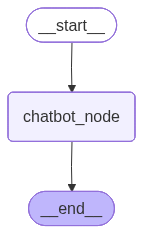

In [7]:
llm = init_chat_model("google_genai:gemini-2.5-flash")

class State(TypedDict):
    messages: Annotated[list, add_messages]

def chatbot(state: State) -> State:
    return {"messages": [llm.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("chatbot_node", chatbot)
builder.add_edge(START, "chatbot_node")
builder.add_edge("chatbot_node", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
message = {"role": "user", "content": "Who walked on the moon for the first time? Print only the name"}
response = graph.invoke({"messages":[message]})
response["messages"]

[HumanMessage(content='Who walked on the moon for the first time? Print only the name', additional_kwargs={}, response_metadata={}, id='8e476378-cd1f-4065-a419-dbec62a4d375'),
 AIMessage(content='Neil Armstrong', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d6844-6617-7643-a8a6-cd70bd7309b4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 51, 'total_tokens': 66, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 49}})]

In [16]:
print(response["messages"][-1].content)

Neil Armstrong


### Creating a Graph with a Tool
$\bullet$ In order to build useful agents, we need to provide tools for agents, So when a person asks a question such as MSFT stock price, LLM should be able to call Yahoo Finance API or some python function to get the latest stock price. (LLM do not know the latest stock price, since its knowledge is cut-off by some date)  
$\bullet$ @tool $\rightarrow$ is a decorator that converts your normal Python function into a structured tool object that the LLM + LangGraph can understand and use.  
$\bullet$ llm.bind_tools() $\rightarrow$ Since we are binding the tool with LLM, the LLM only knows that there exists a tool called "get_stock_price(symbol)" that returns a stock price. The LLM has zero idea how our "get_stock_price()" function works internally.  
$\bullet$ The only understanding about the tool for the LLM comes from: Function name, Parameter names/types, Docstring(MOST IMPORTANT)

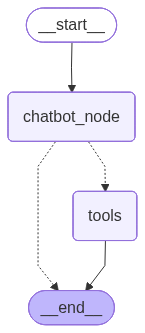

In [2]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

@tool
def get_stock_price(symbol: str) -> float:
    '''Return the current price of a stock given the stock symbol :param symbol: stock symbol :return: current price of the stock'''
    return {"MSFT": 200.3, "AAPL": 100.4, "AMZN": 150.0, "RIL": 87.6}.get(symbol, 0.0)

tools = [get_stock_price]
llm = init_chat_model("google_genai:gemini-2.5-flash")
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State) -> State:
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("chatbot_node", chatbot)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "chatbot_node")
builder.add_conditional_edges("chatbot_node", tools_condition)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

$\bullet$ So here, LLM is smartly figuring out the need to call the tool "get_stock_price". Therefore LLM returns an instruction to call the tool.  
$\bullet$ LangGraph sees that the LLM wants to call the tool and it will call the tool.

In [20]:
state = graph.invoke({"messages": [{"role": "user", "content": "What is the price of AMZN stock right now?"}]})
print(state["messages"][-1].content)

150.0


$\bullet$ Here, Even though LLM does have the knowledge of the tool "get_stock_price", LLM smartly figuring out it does not have to call the tool for this matter.  
$\bullet$ So it returns the answer for the question without any instructions to call the tool.

In [25]:
state = graph.invoke({"messages": [{"role": "user", "content": "Who invented the theory of relativity? print only the name"}]})
print(state["messages"][-1].content)

Albert Einstein


### Creating a Graph with Agentic Behavior
$\bullet$ The agentic behavior comes from the LLM $\leftrightarrow$ tool loop managed by LangGraph  
$\bullet$ The loop continues only if the LLM requests a tool  

    When the LLM responds with a tool call → graph routes to the tools node  
    Tool executes → result goes back to LLM  
    This repeats...

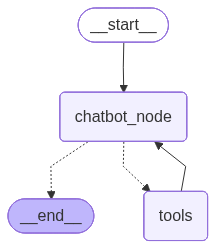

In [3]:
builder = StateGraph(State)
builder.add_node("chatbot_node", chatbot)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "chatbot_node")
builder.add_conditional_edges("chatbot_node", tools_condition)
builder.add_edge("tools", "chatbot_node")
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

$\bullet$ So, after getting response from LLM according to it, LangGraph makes 2 tool calls for "get_stock_price()" and returns AMZN \& MSFT stock prices.  
$\bullet$ Then LangGraph agent calls LLM again to calculate the total cost for 20 AMZN \& 15 MSFT stocks.

In [52]:
msg = "I want to buy 20 AMZN stocks using current price. Then 15 MSFT. what will be the total cost?"
state = graph.invoke({"messages": [{"role": "user", "content": msg}]})
print(state["messages"][-1].content[0]["text"])

The total cost will be $6004.5.


$\bullet$ Here, you can see that LLM is asking the previous total because it doesn't know what happened previously.

In [53]:
msg = "Using the current price tell me the total price of 10 RIL stocks and add it to the previous total"
state = graph.invoke({"messages": [{"role": "user", "content": msg}]})
print(state["messages"][-1].content[0]["text"])

I can tell you the current price of 10 RIL stocks, but I can't add it to a previous total as I have no memory of past conversations or values.


### Giving Memory for the Agent & Maintaining Multiple Conversations

So, we need to maintain memory. For that we need state persistence across invocations.
$$
\textrm{Call 1 in Thread 1 → compute total (AMZN + MSFT)} \\
\textrm{Call 2 in Thread 1 → remember previous total + add RIL}
$$
$\bullet$ memory=MemorySaver() $\rightarrow$ Creates a checkpoint storage system. Stores graph state (messages, tool outputs, etc.)  
$\bullet$ checkpointer=memory $\rightarrow$ Attaches the memory to your graph. Enables: saving state after each step, loading previous state before next run  
$\bullet$ config $\rightarrow$ Defines a unique conversation ID. (MemorySaver can store multiple conversations)

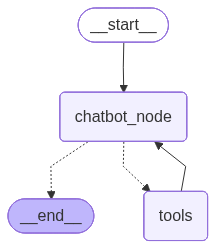

In [4]:
memory = MemorySaver()
builder = StateGraph(State)
builder.add_node("chatbot_node", chatbot)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "chatbot_node")
builder.add_conditional_edges("chatbot_node", tools_condition)
builder.add_edge("tools", "chatbot_node")
graph = builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

Multiple conversations with Thread 1 \& Thread 2
$$
\textrm{Thread 1 → (20 AMZN \& 15 MSFT) + (10 RIL)} \\
\textrm{Thread 2 → (5 AAPL) + (5 MSFT)}
$$

In [5]:
config1 = {'configurable': {'thread_id': '1'}}
msg = "I want to buy 20 AMZN stocks using current price. Then 15 MSFT. what will be the total cost?"
state = graph.invoke({"messages": [{"role": "user", "content": msg}]}, config=config1)
print(state["messages"][-1].content[0]["text"])

The total cost will be 6004.5


In [6]:
config2 = {'configurable': {'thread_id': '2'}}
msg = "I want to buy 5 AAPL stocks at current price. what will be the total cost?"
state = graph.invoke({"messages": [{"role": "user", "content": msg}]}, config=config2)
print(state["messages"][-1].content)

The total cost will be 502.0.


In [ ]:
msg = "Tell me the total price of 10 RIL stocks and add it to the previous total"
state = graph.invoke({"mesages": [{"role": "user", "content": msg}]}, config=config1)
print(state["messages"][-1].content)

In [ ]:
msg = "Tell me the current price of 5 MSFT stocks and add it to previous total"
state = graph.invoke({"mesages": [{"role": "user", "content": msg}]}, config=config2)
print(state["messages"])

### Human In The Loop - HITL
$\bullet$ When we are building agentic workflows, they can't be fully autonomous. Before performing some critical action we want to take some human approval.  
$\bullet$ Let's say we are buying some stocks using some AI system. Before it executes a specific trade we want to make sure everything is perfect and give a human approval.

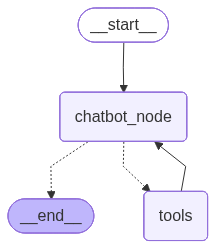

In [24]:
@tool
def get_stock_price(symbol: str) -> float:
    '''Return the current price of a stock given the stock symbol :param symbol: stock symbol :return: current price of the stock'''
    return {"MSFT": 200.3, "AAPL": 100.4, "AMZN": 150.0, "RIL": 87.6}.get(symbol, 0.0)

@tool
def buy_stocks(symbol: str, quantity: int, total_price: float) -> str:
    '''Buy stocks given the stock symbol and quantity'''
    decision = interrupt(f"Approve buying {quantity} shares of {symbol} for a total price of {total_price:.2f}?")
    if (decision == "yes"):
        return f"You bought {quantity} shares of {symbol} for a total price of {total_price}"
    else:
        return "Buying declined"

tools = [get_stock_price, buy_stocks]
llm = init_chat_model("google_genai:gemini-2.5-flash")
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    msg = llm_with_tools.invoke(state["messages"])
    return {"messages": [msg]}

memory = MemorySaver()
builder = StateGraph(State)
builder.add_node("chatbot_node", chatbot)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "chatbot_node")
builder.add_conditional_edges("chatbot_node", tools_condition)
builder.add_edge("tools", "chatbot_node")
builder.add_edge("chatbot_node", END)
graph = builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
config = {"configurable": {"thread_id": "buy_thread"}}

# Step 1: user asks price
state = graph.invoke({"messages":[{"role": "user", "content": "What is the current price of 10 MSFT stocks?"}]}, config=config)
print(state["messages"][-1].content)

# Step 2: user asks to buy
state = graph.invoke({"messages":[{"role": "user", "content": "Buy 10 MSFT stock at current price"}]}, config=config)
print(state.get("__interrupt__"))

decision = input("Approve (yes/no): ")
state = graph.invoke(Command(resume=decision), config=config)
print(state["messages"][-1].content)

The current price of 10 MSFT stocks is 2003.0.
[Interrupt(value='Approve buying 10 shares of MSFT for a total price of 2003.00?', id='f9d052b6360d8606de3ef8064db4792d')]
You bought 10 shares of MSFT for a total price of 2003.0.
